In [1]:
import nltk
import pandas as pd 
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import re
nltk.download('all')

[nltk_data] Downloading collection 'all'
[nltk_data]    | 
[nltk_data]    | Downloading package abc to
[nltk_data]    |     /home/codespace/nltk_data...
[nltk_data]    |   Package abc is already up-to-date!
[nltk_data]    | Downloading package alpino to
[nltk_data]    |     /home/codespace/nltk_data...
[nltk_data]    |   Package alpino is already up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger to
[nltk_data]    |     /home/codespace/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger is already up-
[nltk_data]    |       to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_eng to
[nltk_data]    |     /home/codespace/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_eng is already
[nltk_data]    |       up-to-date!
[nltk_data]    | Downloading package averaged_perceptron_tagger_ru to
[nltk_data]    |     /home/codespace/nltk_data...
[nltk_data]    |   Package averaged_perceptron_tagger_ru is already
[nltk_da

True

In [2]:
df=pd.read_csv("/workspaces/Aress_Task/data/IMDB Dataset.csv")

In [3]:
df.head()

,review,sentiment
0,One of the other reviewers has mentioned that ...,positive
1,A wonderful little production. <br /><br />The...,positive
2,I thought this was a wonderful way to spend ti...,positive
3,Basically there's a family where a little boy ...,negative
4,"Petter Mattei's ""Love in the Time of Money"" is...",positive


In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 50000 entries, 0 to 49999
Data columns (total 2 columns):
 #   Column     Non-Null Count  Dtype
---  ------     --------------  -----
 0   review     50000 non-null  str  
 1   sentiment  50000 non-null  str  
dtypes: str(2)
memory usage: 781.4 KB


In [5]:
df.describe()

,review,sentiment
count,50000,50000
unique,49582,2
top,Loved today's show!!! It was a variety and not...,positive
freq,5,25000


In [6]:
df.isnull().sum()

review       0
sentiment    0
dtype: int64

In [7]:
df.duplicated().sum()

np.int64(418)

In [8]:
df.drop_duplicates(inplace=True)

In [9]:
df['sentiment'].value_counts()

sentiment
positive    24884
negative    24698
Name: count, dtype: int64

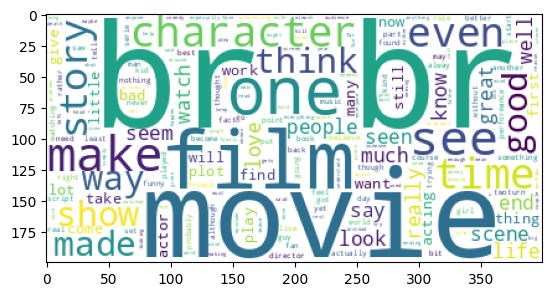

In [11]:
from wordcloud import WordCloud, STOPWORDS
text = " ".join(df['review'].astype(str))
wc=WordCloud(background_color='white').generate(text)
plt.imshow(wc)
plt.show()

**Data Preprocessing**

In [10]:
## Lower Case
df['review']=df['review'].str.lower()

In [11]:
## remove puncuations
df['review'] = df['review'].str.replace(r'[^\w\s]', '', regex=True)

In [12]:
df['review']

0        one of the other reviewers has mentioned that ...
1        a wonderful little production br br the filmin...
2        i thought this was a wonderful way to spend ti...
3        basically theres a family where a little boy j...
4        petter matteis love in the time of money is a ...
                               ...                        
49995    i thought this movie did a down right good job...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    i am a catholic taught in parochial elementary...
49998    im going to have to disagree with the previous...
49999    no one expects the star trek movies to be high...
Name: review, Length: 49582, dtype: str

In [13]:
## adv preprocessing 
from nltk.stem import WordNetLemmatizer
from nltk.tokenize import word_tokenize
from nltk.corpus import stopwords
stop_words=set(stopwords.words('english'))
lemmatizer=WordNetLemmatizer()
def preprocess(text):
    ## Word Token
    words=word_tokenize(text)
    ## remove lemmatization
    words = [lemmatizer.lemmatize(w) for w in words if w not in stop_words and w not in string.punctuation]
    return " ".join(words)

In [14]:
import string

In [15]:
df['clean']=df['review'].astype(str).apply(preprocess)

In [16]:
df['clean']

0        one reviewer mentioned watching 1 oz episode y...
1        wonderful little production br br filming tech...
2        thought wonderful way spend time hot summer we...
3        basically there family little boy jake think t...
4        petter matteis love time money visually stunni...
                               ...                        
49995    thought movie right good job wasnt creative or...
49996    bad plot bad dialogue bad acting idiotic direc...
49997    catholic taught parochial elementary school nu...
49998    im going disagree previous comment side maltin...
49999    one expects star trek movie high art fan expec...
Name: clean, Length: 49582, dtype: str

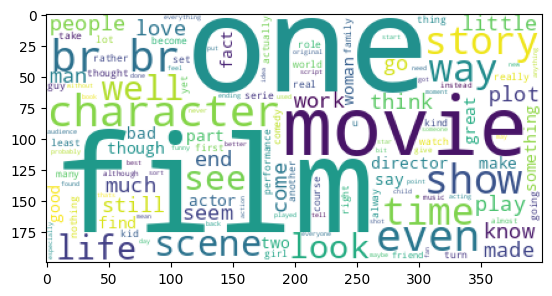

In [19]:
from wordcloud import WordCloud, STOPWORDS
text = " ".join(df['clean'].astype(str))
wc=WordCloud(background_color='white').generate(text)
plt.imshow(wc)
plt.show()

In [22]:
df['sentiment']

0        positive
1        positive
2        positive
3        negative
4        positive
           ...   
49995    positive
49996    negative
49997    negative
49998    negative
49999    negative
Name: sentiment, Length: 49582, dtype: str

In [23]:
from sklearn.preprocessing import LabelEncoder
label=LabelEncoder()
df['sentiment']=label.fit_transform(df['sentiment'])

In [24]:
df.head()

,review,sentiment,clean
0,one of the other reviewers has mentioned that ...,1,one reviewer mentioned watching 1 oz episode y...
1,a wonderful little production br br the filmin...,1,wonderful little production br br filming tech...
2,i thought this was a wonderful way to spend ti...,1,thought wonderful way spend time hot summer we...
3,basically theres a family where a little boy j...,0,basically there family little boy jake think t...
4,petter matteis love in the time of money is a ...,1,petter matteis love time money visually stunni...


In [25]:
from sklearn.model_selection import train_test_split
X=df['review']
y=df['sentiment']

In [26]:
X.shape,y.shape

((49582,), (49582,))

In [27]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42)

In [28]:
## Apply tf-idf
from sklearn.feature_extraction.text import  TfidfVectorizer
tfidf = TfidfVectorizer(max_features=5000)
X_train_tfidf = tfidf.fit_transform(X_train)
X_test_tfidf = tfidf.transform(X_test)



In [29]:
from sklearn.svm import SVC
from sklearn.metrics import classification_report,confusion_matrix,roc_auc_score
model=SVC()

model = SVC(class_weight='balanced')
model.fit(X_train_tfidf,y_train)

y_pred = model.predict(X_test_tfidf)

Report of SVM-Classification
              precision    recall  f1-score   support

           0       0.90      0.88      0.89      4939
           1       0.89      0.91      0.90      4978

    accuracy                           0.89      9917
   macro avg       0.89      0.89      0.89      9917
weighted avg       0.89      0.89      0.89      9917

Confusion Matrix


Text(50.722222222222214, 0.5, 'Predicted')

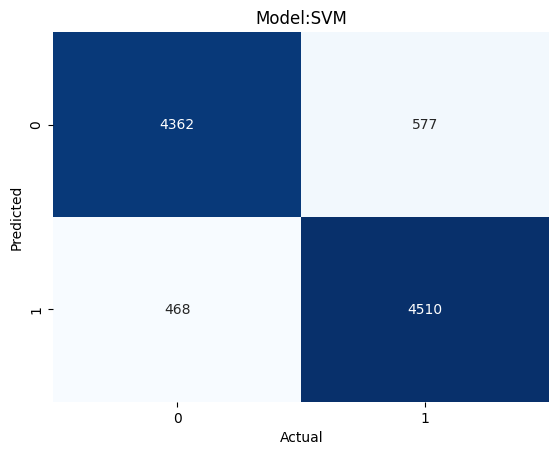

In [30]:

print("Report of SVM-Classification")
print(classification_report(y_test, y_pred))
print("Confusion Matrix")
cm = confusion_matrix(y_test, y_pred)
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', cbar=False)
plt.title("Model:SVM")    
plt.xlabel("Actual")
plt.ylabel('Predicted')